# Computational Thermofluid Dynamics-Finite Difference
==============================================================================================

# Finite Differences
The 2D steady heat equation reads:
$$
\frac{\partial}{\partial x}(\lambda\frac{\partial T}{\partial x}) + \frac{\partial}{\partial y}(\lambda\frac{\partial T}{\partial y}) = 0
$$

# Stage 1 — Derivation of Finite Difference Scheme

Derive a **second-order accurate Finite Difference (FD)** scheme for the **2D steady-state heat equation** with **constant thermal conductivity** $\lambda$.  
Assume **Dirichlet boundary conditions** are applied on all sides of the domain.

Your task:
1. Start from the continuous governing equation  
   $$
   \frac{\partial}{\partial x}\!\left(\lambda \frac{\partial T}{\partial x}\right)
   + \frac{\partial}{\partial y}\!\left(\lambda \frac{\partial T}{\partial y}\right) = 0
   $$
2. Apply **central differencing** to discretize spatial derivatives.  
3. Present your **discrete equation** in **LaTeX format** below.



Since $\lambda$ is constant, the 2D steady heat equation can be written as:

$$
\lambda \left( \frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} \right) = 0
$$

Dividing by $\lambda$ ($\lambda \neq 0$):

$$
\frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} = 0
$$

Define a rectangular grid with $i$ as index in x-direction, $j$ as index in y-direction, $\Delta x$ and $\Delta y$ as grid spacings, and temperature at $(i,j)$ denoted as $T_{i,j}$.

Using Taylor series expansions around point $(i,j)$:

Forward expansion (at $i+1,j$):
$$
T_{i+1,j} = T_{i,j} + \Delta x \frac{\partial T}{\partial x}\bigg|_{i,j} + \frac{(\Delta x)^2}{2} \frac{\partial^2 T}{\partial x^2}\bigg|_{i,j} + \frac{(\Delta x)^3}{6} \frac{\partial^3 T}{\partial x^3}\bigg|_{i,j} + \mathcal{O}((\Delta x)^4)
$$

Backward expansion (at $i-1,j$):
$$
T_{i-1,j} = T_{i,j} - \Delta x \frac{\partial T}{\partial x}\bigg|_{i,j} + \frac{(\Delta x)^2}{2} \frac{\partial^2 T}{\partial x^2}\bigg|_{i,j} - \frac{(\Delta x)^3}{6} \frac{\partial^3 T}{\partial x^3}\bigg|_{i,j} + \mathcal{O}((\Delta x)^4)
$$

Add these two equations:
$$
T_{i+1,j} + T_{i-1,j} = 2T_{i,j} + (\Delta x)^2 \frac{\partial^2 T}{\partial x^2}\bigg|_{i,j} + \mathcal{O}((\Delta x)^4)
$$

Rearrange to solve for the second derivative:
$$
\frac{\partial^2 T}{\partial x^2}\bigg|_{i,j} = \frac{T_{i+1,j} - 2T_{i,j} + T_{i-1,j}}{(\Delta x)^2} + \mathcal{O}((\Delta x)^2)
$$

Similarly for y-direction:

Forward expansion (at $i,j+1$):
$$
T_{i,j+1} = T_{i,j} + \Delta y \frac{\partial T}{\partial y}\bigg|_{i,j} + \frac{(\Delta y)^2}{2} \frac{\partial^2 T}{\partial y^2}\bigg|_{i,j} + \frac{(\Delta y)^3}{6} \frac{\partial^3 T}{\partial y^3}\bigg|_{i,j} + \mathcal{O}((\Delta y)^4)
$$

Backward expansion (at $i,j-1$):
$$
T_{i,j-1} = T_{i,j} - \Delta y \frac{\partial T}{\partial y}\bigg|_{i,j} + \frac{(\Delta y)^2}{2} \frac{\partial^2 T}{\partial y^2}\bigg|_{i,j} - \frac{(\Delta y)^3}{6} \frac{\partial^3 T}{\partial y^3}\bigg|_{i,j} + \mathcal{O}((\Delta y)^4)
$$

Add these two equations:
$$
T_{i,j+1} + T_{i,j-1} = 2T_{i,j} + (\Delta y)^2 \frac{\partial^2 T}{\partial y^2}\bigg|_{i,j} + \mathcal{O}((\Delta y)^4)
$$

Rearrange:
$$
\frac{\partial^2 T}{\partial y^2}\bigg|_{i,j} = \frac{T_{i,j+1} - 2T_{i,j} + T_{i,j-1}}{(\Delta y)^2} + \mathcal{O}((\Delta y)^2)
$$

Substitute both finite difference approximations into the Laplace equation:

$$
\frac{T_{i+1,j} - 2T_{i,j} + T_{i-1,j}}{(\Delta x)^2} + \frac{T_{i,j+1} - 2T_{i,j} + T_{i,j-1}}{(\Delta y)^2} = 0
$$

For equal grid spacing $\Delta x = \Delta y = h$:

$$
\frac{T_{i+1,j} - 2T_{i,j} + T_{i-1,j}}{h^2} + \frac{T_{i,j+1} - 2T_{i,j} + T_{i,j-1}}{h^2} = 0
$$

Multiply through by $h^2$:

$$
(T_{i+1,j} - 2T_{i,j} + T_{i-1,j}) + (T_{i,j+1} - 2T_{i,j} + T_{i,j-1}) = 0
$$

Simplify:

$$
T_{i+1,j} + T_{i-1,j} + T_{i,j+1} + T_{i,j-1} - 4T_{i,j} = 0
$$

This is the 5-point stencil for the Laplace equation.

The final discrete equations:

For general grid spacing:
$$
\frac{T_{i+1,j} - 2T_{i,j} + T_{i-1,j}}{(\Delta x)^2} + \frac{T_{i,j+1} - 2T_{i,j} + T_{i,j-1}}{(\Delta y)^2} = 0
$$

For equal grid spacing ($\Delta x = \Delta y = h$):
$$
T_{i+1,j} + T_{i-1,j} + T_{i,j+1} + T_{i,j-1} - 4T_{i,j} = 0
$$

From the Taylor series analysis, the x-derivative approximation has error $\mathcal{O}((\Delta x)^2)$, the y-derivative approximation has error $\mathcal{O}((\Delta y)^2)$, and the overall scheme is second-order accurate in space.

For implementation, the discrete equation can be written as:

$$
\frac{1}{(\Delta x)^2}T_{i+1,j} + \frac{1}{(\Delta x)^2}T_{i-1,j} + \frac{1}{(\Delta y)^2}T_{i,j+1} + \frac{1}{(\Delta y)^2}T_{i,j-1} - 2\left(\frac{1}{(\Delta x)^2} + \frac{1}{(\Delta y)^2}\right)T_{i,j} = 0
$$
Also, descritized form of the equation in case of source is given below:
$$
 \left[2λ\left(\frac{1}{Δx²} + \frac{1}{Δy²}\right)\right] T_{i,j} - \left(\frac{λ}{Δx²}\right) T_{i+1,j} - \left(\frac{λ}{Δx²}\right) T_{i-1,j}- \left(\frac{λ}{Δy²}\right) T_{i,j+1}- \left(\frac{λ}{Δy²}\right) T_{i,j-1} = S_{i,j}
 $$


# Stage 2 — Implementation of 2D Steady-State Heat Conduction Solver

Using the provided class templates, implement a **2D steady-state heat conduction solver** with **Dirichlet, Robin and Neumann boundary conditions**.  
The solver should assemble and solve the linear system corresponding to the discretized finite difference equations derived in **Stage 1**.

Note that: The corner nodes are assigned as follows for this exercise:

SouthWest, NorthWest -> West

SouthEast, NorthEast -> East

Later in Finite Volume exercise, we will learn how to discretize them more precisely!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import spsolve

class Source:
    def __init__(self, location, is_active, q_dot):
        self.location = tuple(location)  # (x,y) physical coords
        self.is_active = bool(is_active)
        self.q_dot = float(q_dot)        # total power Q [W]

class SteadyHeat2D:
    def __init__(self, Lx, Ly, dimX, dimY, source):
        # domain and grid
        self.l = float(Lx)
        self.h = float(Ly)
        self.dimX = int(dimX)
        self.dimY = int(dimY)

        # thermal conductivity (change if needed)
        self.lambda_val = 1.0

        # source
        self.source_location = tuple(source.location)
        self.source_active = bool(source.is_active)
        self.source_Q = float(source.q_dot)

        # grid spacing
        self.dx = self.l / (self.dimX - 1)
        self.dy = self.h / (self.dimY - 1)

        # Use sparse matrix for better performance
        self.total_nodes = self.dimX * self.dimY
        self.A = None  # Will be sparse matrix
        self.b = np.zeros(self.total_nodes, dtype=float)

        # BC holders
        self.bc_south_set = False
        self.bc_north_set = False
        self.bc_west_set = False
        self.bc_east_set = False
        self.bc_south = {}
        self.bc_north = {}
        self.bc_west = {}
        self.bc_east = {}

        # optional user overrides (tweak before solve if desired)
        # self._user_sigma = 0.08         # uncomment & set to force Gaussian sigma (meters)
        # self._source_thickness = 1.0    # uncomment & set if modelling thin plate (m)

    def _get_index(self, i, j):
        return i * self.dimY + j

    # ---------------- assemble linear system ------------------------------
    def set_inner(self):
        """Assemble coefficient matrix A and RHS vector b using sparse matrices."""
        # Initialize sparse matrix in LIL format for efficient construction
        self.A = sparse.lil_matrix((self.total_nodes, self.total_nodes), dtype=float)
        self.b.fill(0.0)

        alpha_x = self.lambda_val / (self.dx ** 2)
        alpha_y = self.lambda_val / (self.dy ** 2)

        # interior nodes
        for i in range(1, self.dimX - 1):
            for j in range(1, self.dimY - 1):
                idx = self._get_index(i, j)
                self.A[idx, idx] = 2.0 * (alpha_x + alpha_y)
                self.A[idx, self._get_index(i+1, j)] = -alpha_x
                self.A[idx, self._get_index(i-1, j)] = -alpha_x
                self.A[idx, self._get_index(i, j+1)] = -alpha_y
                self.A[idx, self._get_index(i, j-1)] = -alpha_y

        # apply BCs (these overwrite rows)
        if self.bc_south_set: self._apply_south_bc()
        if self.bc_north_set: self._apply_north_bc()
        if self.bc_west_set: self._apply_west_bc()
        if self.bc_east_set: self._apply_east_bc()

        # Convert to CSR format for efficient solving
        self.A = self.A.tocsr()

        # add source (Gaussian)
        if self.source_active:
            self._add_heat_source()

    # ---------------- Gaussian source (main implementation) ---------------
    def _add_gaussian_source(self):
        """
        Add a Gaussian-distributed source centered at source_location.
        Normalized so total integrated power = self.source_Q [W].
        """
        Q_total = float(self.source_Q)
        x_s, y_s = self.source_location

        # decide sigma: user override or automatic sensible default
        if hasattr(self, '_user_sigma') and self._user_sigma is not None:
            sigma = float(self._user_sigma)
        else:
            # default: at least ~2 grid cells wide or ~4% of domain
            sigma = max(2.0 * max(self.dx, self.dy), 0.04 * max(self.l, self.h))

        # build physical grid
        x = np.linspace(0.0, self.l, self.dimX)
        y = np.linspace(0.0, self.h, self.dimY)
        X, Y = np.meshgrid(x, y, indexing='ij')

        # unnormalized Gaussian
        q_raw = np.exp(-((X - x_s)**2 + (Y - y_s)**2) / (2.0 * sigma**2))

        # normalize to give total power Q_total: integral(q_raw dA) * scale = Q_total
        area_integral = np.sum(q_raw) * self.dx * self.dy
        if area_integral <= 1e-12:  # More robust check
            return
        q_surface = q_raw * (Q_total / area_integral)   # [W/m^2]

        # convert surface density to volumetric generation [W/m^3] using thickness (default 1 m)
        thickness = getattr(self, '_source_thickness', 1.0)
        if thickness <= 0.0:
            thickness = 1.0
        S_vol = q_surface / float(thickness)   # [W/m^3]

        # add into RHS vector (flatten order matches A/T ordering)
        self.b += S_vol.flatten()

    # ---------------- renamed wrapper function --------------------------
    def _add_heat_source(self):
        """
        Add heat source to the domain.
        Internally uses a Gaussian source (physically realistic).
        """
        self._add_gaussian_source()

    # ---------------- boundary setters -----------------------------------
    def set_south(self, bc_type, T_d=0.0, q=0.0, alpha=0.0, T_inf=0.0):
        self.bc_south_set = True
        self.bc_south = {'type': bc_type, 'T_d': T_d, 'q': q, 'alpha': alpha, 'T_inf': T_inf}

    def set_north(self, bc_type, T_d=0.0, q=0.0, alpha=0.0, T_inf=0.0):
        self.bc_north_set = True
        self.bc_north = {'type': bc_type, 'T_d': T_d, 'q': q, 'alpha': alpha, 'T_inf': T_inf}

    def set_west(self, bc_type, T_d=0.0, q=0.0, alpha=0.0, T_inf=0.0):
        self.bc_west_set = True
        self.bc_west = {'type': bc_type, 'T_d': T_d, 'q': q, 'alpha': alpha, 'T_inf': T_inf}

    def set_east(self, bc_type, T_d=0.0, q=0.0, alpha=0.0, T_inf=0.0):
        self.bc_east_set = True
        self.bc_east = {'type': bc_type, 'T_d': T_d, 'q': q, 'alpha': alpha, 'T_inf': T_inf}

    # ---------------- boundary appliers ---------------------------------
    def _apply_south_bc(self):
        bc = self.bc_south
        bc_type = bc['type']
        if bc_type == 'D':
            T_d = bc['T_d']
            for i in range(self.dimX):
                idx = self._get_index(i, 0)
                # Clear row and set Dirichlet condition
                self.A[idx, :] = 0.0
                self.A[idx, idx] = 1.0
                self.b[idx] = T_d
        elif bc_type == 'N':
            q = bc['q']
            for i in range(self.dimX):
                idx = self._get_index(i, 0)
                idx_up = self._get_index(i, 1)
                # Clear row and set Neumann condition
                self.A[idx, :] = 0.0
                self.A[idx, idx] = self.lambda_val / self.dy
                self.A[idx, idx_up] = -self.lambda_val / self.dy
                self.b[idx] = q
        elif bc_type == 'R':
            alpha = bc['alpha']; T_inf = bc['T_inf']
            for i in range(self.dimX):
                idx = self._get_index(i, 0); idx_up = self._get_index(i, 1)
                # Clear row and set Robin condition
                self.A[idx, :] = 0.0
                self.A[idx, idx] = self.lambda_val / self.dy + alpha
                self.A[idx, idx_up] = -self.lambda_val / self.dy
                self.b[idx] = alpha * T_inf

    def _apply_north_bc(self):
        bc = self.bc_north
        bc_type = bc['type']
        if bc_type == 'D':
            T_d = bc['T_d']
            for i in range(self.dimX):
                idx = self._get_index(i, self.dimY - 1)
                # Clear row and set Dirichlet condition
                self.A[idx, :] = 0.0
                self.A[idx, idx] = 1.0
                self.b[idx] = T_d
        elif bc_type == 'N':
            q = bc['q']
            for i in range(self.dimX):
                idx = self._get_index(i, self.dimY - 1); idx_dn = self._get_index(i, self.dimY - 2)
                # Clear row and set Neumann condition
                self.A[idx, :] = 0.0
                self.A[idx, idx] = self.lambda_val / self.dy
                self.A[idx, idx_dn] = -self.lambda_val / self.dy
                self.b[idx] = q
        elif bc_type == 'R':
            alpha = bc['alpha']; T_inf = bc['T_inf']
            for i in range(self.dimX):
                idx = self._get_index(i, self.dimY - 1); idx_dn = self._get_index(i, self.dimY - 2)
                # Clear row and set Robin condition
                self.A[idx, :] = 0.0
                self.A[idx, idx] = self.lambda_val / self.dy + alpha
                self.A[idx, idx_dn] = -self.lambda_val / self.dy
                self.b[idx] = alpha * T_inf

    def _apply_west_bc(self):
        bc = self.bc_west
        bc_type = bc['type']
        if bc_type == 'D':
            T_d = bc['T_d']
            for j in range(self.dimY):
                idx = self._get_index(0, j)
                # Clear row and set Dirichlet condition
                self.A[idx, :] = 0.0
                self.A[idx, idx] = 1.0
                self.b[idx] = T_d
        elif bc_type == 'N':
            q = bc['q']
            for j in range(self.dimY):
                idx = self._get_index(0, j); idx_r = self._get_index(1, j)
                # Clear row and set Neumann condition
                self.A[idx, :] = 0.0
                self.A[idx, idx] = self.lambda_val / self.dx
                self.A[idx, idx_r] = -self.lambda_val / self.dx
                self.b[idx] = q
        elif bc_type == 'R':
            alpha = bc['alpha']; T_inf = bc['T_inf']
            for j in range(self.dimY):
                idx = self._get_index(0, j); idx_r = self._get_index(1, j)
                # Clear row and set Robin condition
                self.A[idx, :] = 0.0
                self.A[idx, idx] = self.lambda_val / self.dx + alpha
                self.A[idx, idx_r] = -self.lambda_val / self.dx
                self.b[idx] = alpha * T_inf

    def _apply_east_bc(self):
        bc = self.bc_east
        bc_type = bc['type']
        if bc_type == 'D':
            T_d = bc['T_d']
            for j in range(self.dimY):
                idx = self._get_index(self.dimX - 1, j)
                # Clear row and set Dirichlet condition
                self.A[idx, :] = 0.0
                self.A[idx, idx] = 1.0
                self.b[idx] = T_d
        elif bc_type == 'N':
            q = bc['q']
            for j in range(self.dimY):
                idx = self._get_index(self.dimX - 1, j); idx_l = self._get_index(self.dimX - 2, j)
                # Clear row and set Neumann condition
                self.A[idx, :] = 0.0
                self.A[idx, idx] = self.lambda_val / self.dx
                self.A[idx, idx_l] = -self.lambda_val / self.dx
                self.b[idx] = q
        elif bc_type == 'R':
            alpha = bc['alpha']; T_inf = bc['T_inf']
            for j in range(self.dimY):
                idx = self._get_index(self.dimX - 1, j); idx_l = self._get_index(self.dimX - 2, j)
                # Clear row and set Robin condition
                self.A[idx, :] = 0.0
                self.A[idx, idx] = self.lambda_val / self.dx + alpha
                self.A[idx, idx_l] = -self.lambda_val / self.dx
                self.b[idx] = alpha * T_inf

    # ---------------- solve ------------------------------------------------
    def solve(self):
        """Assemble and solve A·T = b using sparse solver with fallback."""
        self.set_inner()
        
        try:
            # Try sparse solver first (much faster for large problems)
            T_flat = spsolve(self.A, self.b)
        except (ValueError, RuntimeError) as e:
            print(f"Sparse solver failed: {e}. Falling back to dense solver.")
            # Fallback to dense solver if sparse fails
            A_dense = self.A.toarray()
            try:
                T_flat = np.linalg.solve(A_dense, self.b)
            except np.linalg.LinAlgError:
                print("Dense solver also failed. Using least squares solution.")
                T_flat = np.linalg.lstsq(A_dense, self.b, rcond=None)[0]
        
        T = T_flat.reshape((self.dimX, self.dimY))
        return T

    # ---------------- plotting ----------------------------------------------
    def plot(self, TemperatureField):
        x = np.linspace(0, self.l, self.dimX)
        y = np.linspace(0, self.h, self.dimY)
        X, Y = np.meshgrid(x, y, indexing='ij')

        plt.figure(figsize=(8,6))
        cf = plt.contourf(X, Y, TemperatureField, levels=50, cmap='jet')  # blue->green->red
        plt.colorbar(cf, label='Temperature')
        plt.contour(X, Y, TemperatureField, levels=10, colors='k', linewidths=0.5, alpha=0.6)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('2D Steady-State Temperature Distribution')
        plt.gca().set_aspect('equal', adjustable='box')
        plt.show()

# Stage 3 — Test Case 1: All Dirichlet Boundary Conditions

Validate your solver by testing a simple case with **Dirichlet boundaries on all sides**.  
No internal heat source is active. The temperature field should show a smooth gradient
between the hot and cold boundaries.

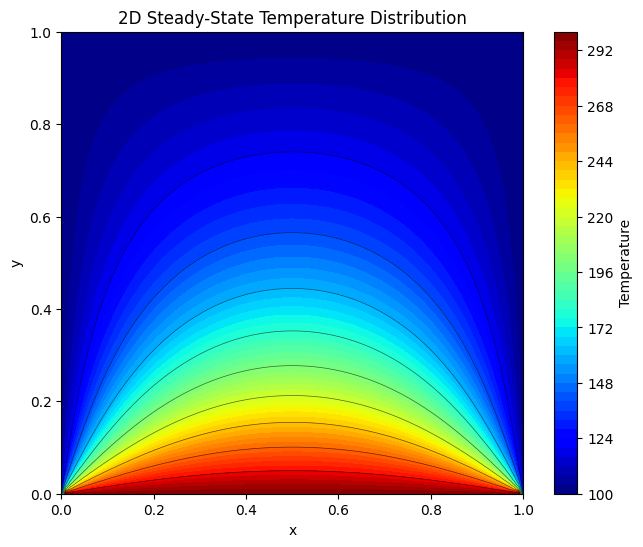

In [2]:
# ================================================================
# Test Case 1 — All Dirichlet Boundary Conditions
# ================================================================

# Domain and grid setup
Lx = 1.0
Ly = 1.0
dimX = 101
dimY = 101

# Point source (inactive for this test)
source = Source(location=[0.5, 0.5], is_active=False, q_dot=0.0)

# Initialize solver
heat = SteadyHeat2D(Lx, Ly, dimX, dimY, source)

# Apply boundary conditions
heat.set_south('D', T_d=300)   # Bottom boundary (hot)
heat.set_north('D', T_d=100)   # Top boundary
heat.set_east('D',  T_d=100)   # Right boundary
heat.set_west('D',  T_d=100)   # Left boundary

# Solve for temperature field
T = heat.solve() # expect shape = (dimX, dimY)

# Visualize result
heat.plot(T)


# Stage 3 — Test Case 2 : Mixed Boundary Conditions

Validate your solver by running a case with **mixed boundary types** to verify correct handling of  
**Dirichlet**, **Neumann**, and **Robin** conditions simultaneously.  
No internal heat source is active.

The temperature field should smoothly transition from the fixed west boundary to the other sides.


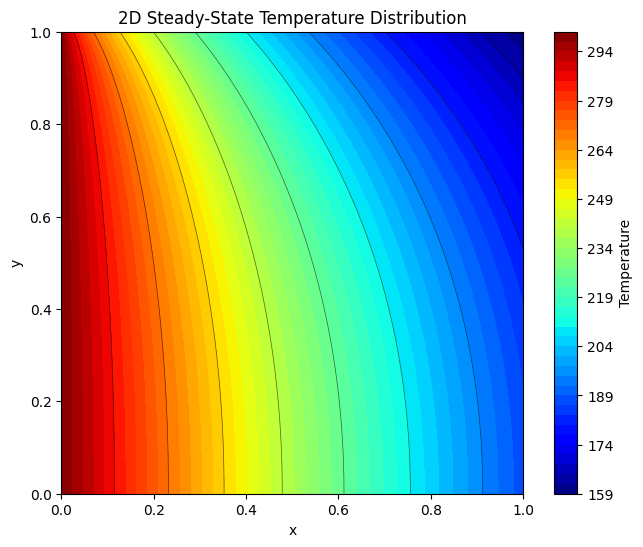

In [3]:
# ================================================================
# Test Case 2 — Mixed Boundary Conditions - Original Case
# ================================================================

# Domain and grid setup
Lx = 1.0
Ly = 1.0
dimX = 101
dimY = 101

# Point source (inactive for this test)
source = Source(location=[0.5, 0.5], is_active=False, q_dot=0.0)

# Apply boundary conditions
heat = SteadyHeat2D(Lx, Ly, dimX, dimY, source)
heat.set_south('N', q = 0.0)
heat.set_north('R', alpha = 1.0, T_inf = 100)
heat.set_east('R', alpha = 1.0, T_inf = 100)
heat.set_west('D', T_d = 300)

# Solve for temperature field
T = heat.solve() # expect shape = (dimX, dimY)

# Visualize result
heat.plot(T)

# Stage 3 — Test Case 3 : Mixed Boundary Conditions with Point Source is Active

Validate your solver by running a case with **mixed boundary types** to verify correct handling of  
**Dirichlet**, **Neumann**, and **Robin** conditions simultaneously.  
Internal heat source is active.



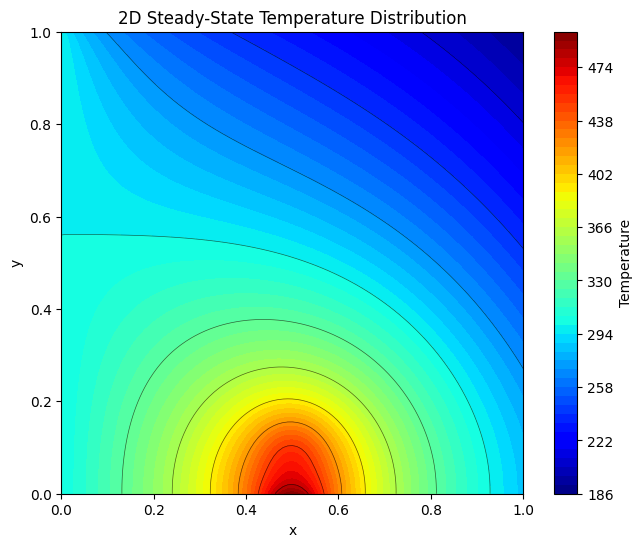

In [4]:
# ================================================================
# Test Case 3 — Mixed Boundary Conditions with Point Source is Active
# ================================================================

# Domain and grid setup
Lx = 1.0
Ly = 1.0
dimX = 101
dimY = 101

# Point source (ACTIVE for this test)
source = Source(location=[0.5, 0.1], is_active=True, q_dot=200,)

# Apply boundary conditions
heat = SteadyHeat2D(Lx, Ly, dimX, dimY, source)
heat.set_south('N', q=0.0)
heat.set_north('R', alpha=1.0, T_inf=100)
heat.set_east('R', alpha=1.0, T_inf=100)
heat.set_west('D', T_d=300)

# Solve for temperature field
T = heat.solve() # expect shape = (dimX, dimY)

# Visualize result
heat.plot(T)

# You can also use the enhanced plotting methods:
# heat.plot_temperature(T, show_grid=False)  # Enhanced 2D plot
# heat.plot_3d(T)  # 3D surface plot

# Stage 4 — Variable Thermal Conductivity (Optional)

Extend your steady-state heat conduction solver to handle **spatially varying thermal conductivity** λ(x, y).  
Do not change anything above — start working **independently** in the cell below cell.  
A new class can be written from scratch, you may copy the class above and implement the necessary changes.

Eq. (2.50) should now be discretized by considering λ depending on space.

Given below is the descritized equation in case of variable conductivity by using finite difference method:
$$
\left[\frac{(λ_{i-1/2,j} + λ_{i+1/2,j})}{Δx²} + \frac{(λ_{i,j-1/2} + λ_{i,j+1/2})}{Δy²}\right] T_{i,j}- \left(\frac{λ_{i+1/2,j}}{Δx²}\right) T_{i+1,j}- \left(\frac{λ_{i-1/2,j}}{Δx²}\right) T_{i-1,j}- \left(\frac{λ_{i,j+1/2}}{Δy²}\right) T_{i,j+1}- \left(\frac{λ_{i,j-1/2}}{Δy²}\right) T_{i,j-1}= S_{i,j}
$$



COMPARISON: Constant vs Variable Conductivity

Test Case 1 Comparison - All Dirichlet BCs
----------------------------------------


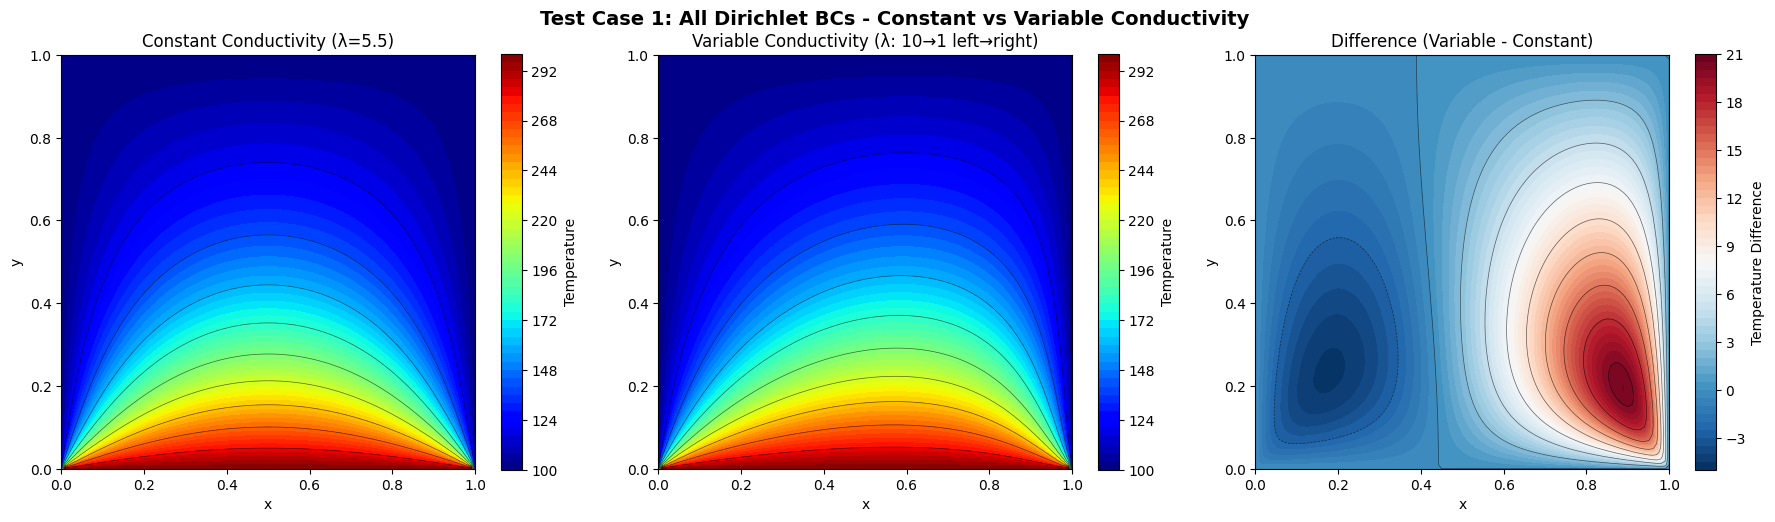


Test Case 2 Comparison - Mixed BCs
----------------------------------------


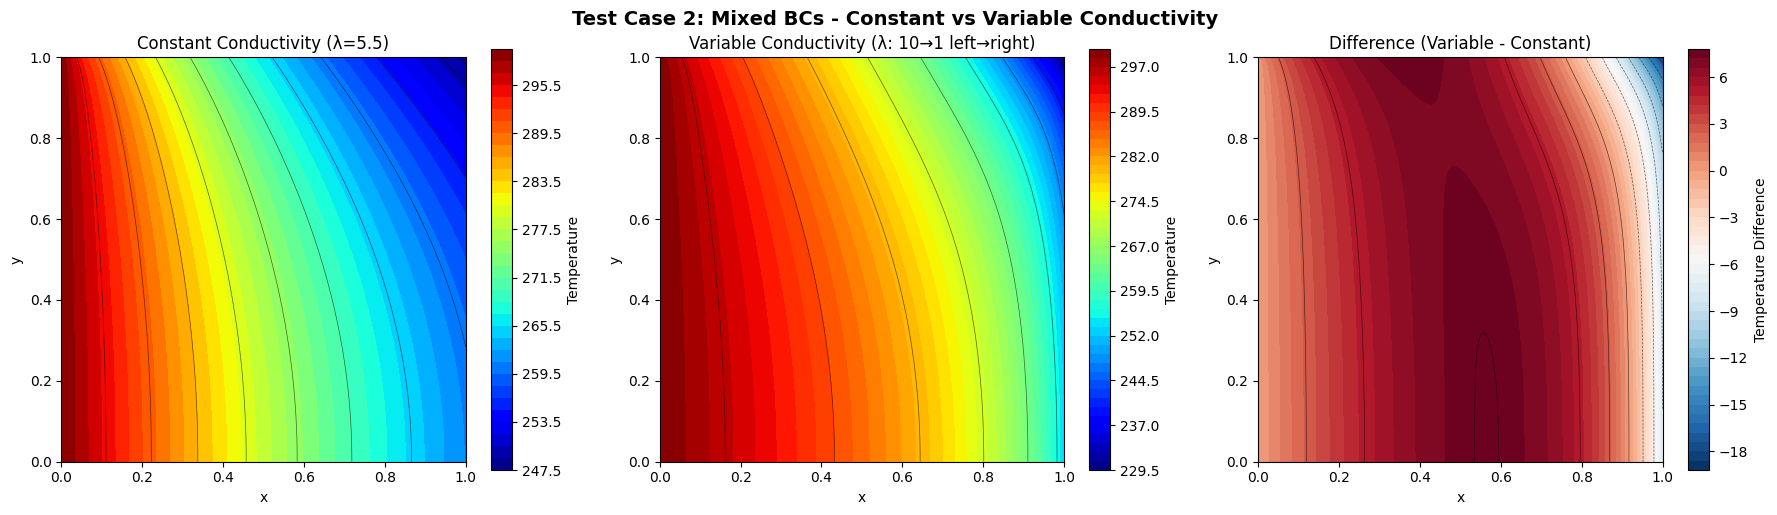


Test Case 3 Comparison - Mixed BCs with Active Source
----------------------------------------


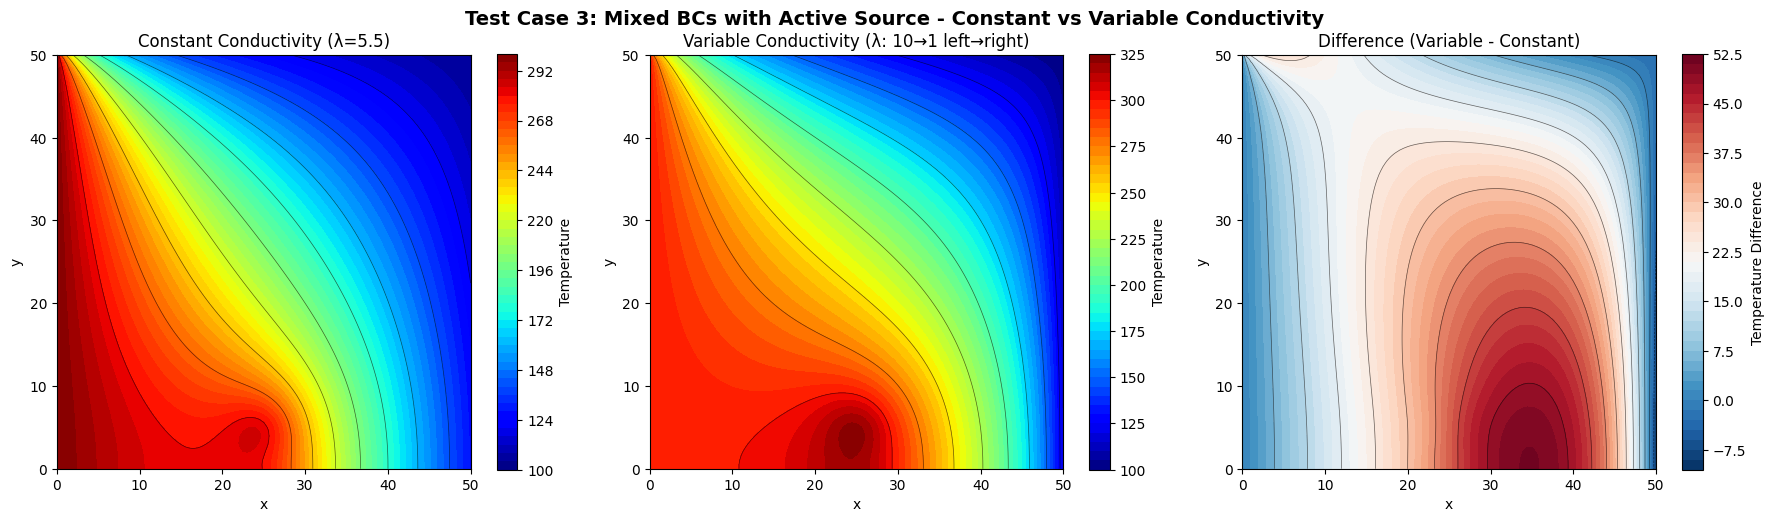


Thermal Conductivity Distribution
----------------------------------------


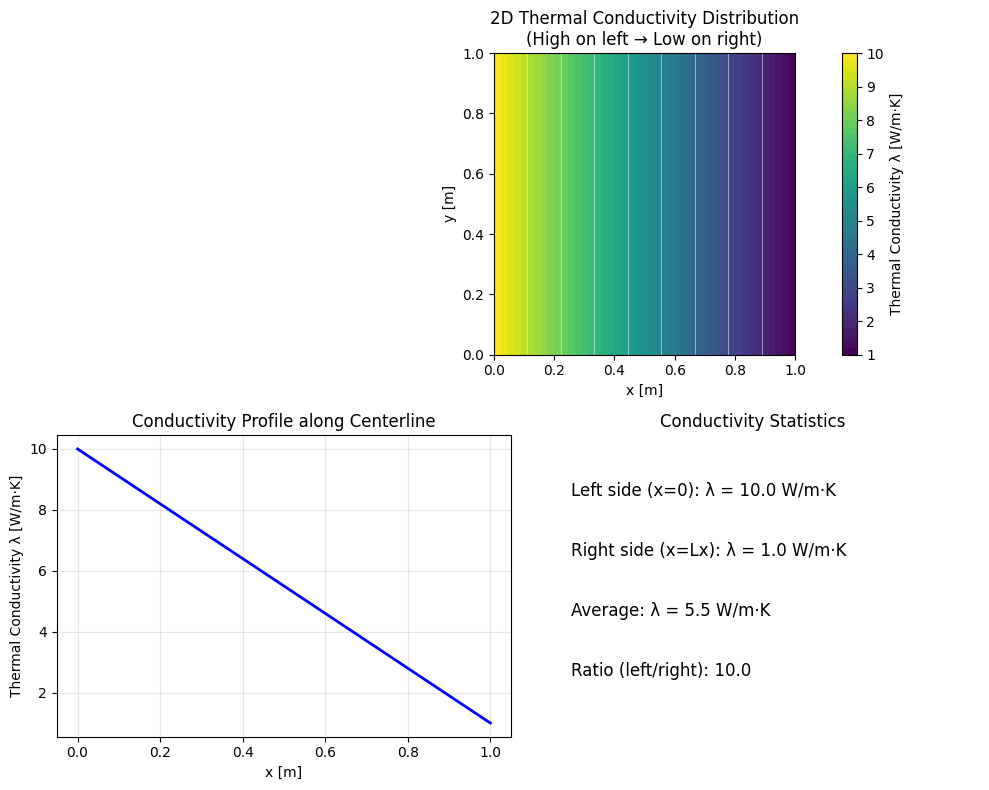

In [5]:
class SteadyHeat2DVariableLambda:
    def __init__(self, Lx, Ly, dimX, dimY, source, lambda_func):
        # domain and grid
        self.l = float(Lx)
        self.h = float(Ly)
        self.dimX = int(dimX)
        self.dimY = int(dimY)

        # thermal conductivity function λ(x, y)
        self.lambda_func = lambda_func

        # source
        self.source_location = tuple(source.location)
        self.source_active = bool(source.is_active)
        self.source_Q = float(source.q_dot)

        # grid spacing
        self.dx = self.l / (self.dimX - 1)
        self.dy = self.h / (self.dimY - 1)

        # Use sparse matrix for better performance
        self.total_nodes = self.dimX * self.dimY
        self.A = None  # Will be sparse matrix
        self.b = np.zeros(self.total_nodes, dtype=float)

        # BC holders
        self.bc_south_set = False
        self.bc_north_set = False
        self.bc_west_set = False
        self.bc_east_set = False
        self.bc_south = {}
        self.bc_north = {}
        self.bc_west = {}
        self.bc_east = {}

        # optional user overrides
        # self._user_sigma = 0.08
        # self._source_thickness = 1.0

    def _get_index(self, i, j):
        return i * self.dimY + j

    def _get_lambda_at_node(self, i, j):
        """Get thermal conductivity at grid node (i,j)"""
        x = i * self.dx
        y = j * self.dy
        return self.lambda_func(x, y)

    def _get_lambda_at_interface(self, i, j, direction):
        """
        Get harmonic mean of thermal conductivity at interface between nodes
        direction: 'x' for interface between (i-1,j) and (i,j)
                   'y' for interface between (i,j-1) and (i,j)
        """
        if direction == 'x':
            # Interface between (i-1,j) and (i,j)
            lambda_left = self._get_lambda_at_node(i-1, j)
            lambda_right = self._get_lambda_at_node(i, j)
            if lambda_left == 0 or lambda_right == 0:
                return 0.0
            # Harmonic mean for thermal conductivity
            return 2.0 * lambda_left * lambda_right / (lambda_left + lambda_right)
        
        elif direction == 'y':
            # Interface between (i,j-1) and (i,j)
            lambda_bottom = self._get_lambda_at_node(i, j-1)
            lambda_top = self._get_lambda_at_node(i, j)
            if lambda_bottom == 0 or lambda_top == 0:
                return 0.0
            # Harmonic mean for thermal conductivity
            return 2.0 * lambda_bottom * lambda_top / (lambda_bottom + lambda_top)
        
        else:
            raise ValueError("Direction must be 'x' or 'y'")

    def set_inner(self):
        """Assemble coefficient matrix A and RHS vector b for variable λ case."""
        # Initialize sparse matrix in LIL format
        self.A = sparse.lil_matrix((self.total_nodes, self.total_nodes), dtype=float)
        self.b.fill(0.0)

        # Precompute interface conductivities for efficiency
        lambda_x = np.zeros((self.dimX, self.dimY))
        lambda_y = np.zeros((self.dimX, self.dimY))
        
        # x-direction interfaces (between i-1 and i)
        for i in range(1, self.dimX):
            for j in range(self.dimY):
                lambda_x[i,j] = self._get_lambda_at_interface(i, j, 'x')
        
        # y-direction interfaces (between j-1 and j)
        for i in range(self.dimX):
            for j in range(1, self.dimY):
                lambda_y[i,j] = self._get_lambda_at_interface(i, j, 'y')

        # interior nodes
        for i in range(1, self.dimX - 1):
            for j in range(1, self.dimY - 1):
                idx = self._get_index(i, j)
                
                # Coefficients for x-direction
                alpha_x_right = lambda_x[i+1, j] / (self.dx ** 2)
                alpha_x_left = lambda_x[i, j] / (self.dx ** 2)
                
                # Coefficients for y-direction  
                alpha_y_top = lambda_y[i, j+1] / (self.dy ** 2)
                alpha_y_bottom = lambda_y[i, j] / (self.dy ** 2)
                
                # Main diagonal
                self.A[idx, idx] = alpha_x_left + alpha_x_right + alpha_y_bottom + alpha_y_top
                
                # Neighbors
                self.A[idx, self._get_index(i+1, j)] = -alpha_x_right
                self.A[idx, self._get_index(i-1, j)] = -alpha_x_left
                self.A[idx, self._get_index(i, j+1)] = -alpha_y_top
                self.A[idx, self._get_index(i, j-1)] = -alpha_y_bottom

        # apply BCs
        if self.bc_south_set: self._apply_south_bc()
        if self.bc_north_set: self._apply_north_bc()
        if self.bc_west_set: self._apply_west_bc()
        if self.bc_east_set: self._apply_east_bc()

        # Convert to CSR format for efficient solving
        self.A = self.A.tocsr()

        # add source
        if self.source_active:
            self._add_heat_source()

    def _add_heat_source(self):
        """Add Gaussian heat source (same as before)"""
        self._add_gaussian_source()

    def _add_gaussian_source(self):
        """Gaussian source implementation (same as before)"""
        Q_total = float(self.source_Q)
        x_s, y_s = self.source_location

        # decide sigma
        if hasattr(self, '_user_sigma') and self._user_sigma is not None:
            sigma = float(self._user_sigma)
        else:
            sigma = max(2.0 * max(self.dx, self.dy), 0.04 * max(self.l, self.h))

        # build physical grid
        x = np.linspace(0.0, self.l, self.dimX)
        y = np.linspace(0.0, self.h, self.dimY)
        X, Y = np.meshgrid(x, y, indexing='ij')

        # unnormalized Gaussian
        q_raw = np.exp(-((X - x_s)**2 + (Y - y_s)**2) / (2.0 * sigma**2))

        # normalize
        area_integral = np.sum(q_raw) * self.dx * self.dy
        if area_integral <= 1e-12:
            return
        q_surface = q_raw * (Q_total / area_integral)

        # convert to volumetric generation
        thickness = getattr(self, '_source_thickness', 1.0)
        if thickness <= 0.0:
            thickness = 1.0
        S_vol = q_surface / float(thickness)

        # add into RHS vector
        self.b += S_vol.flatten()

    # Boundary condition setters (same as before)
    def set_south(self, bc_type, T_d=0.0, q=0.0, alpha=0.0, T_inf=0.0):
        self.bc_south_set = True
        self.bc_south = {'type': bc_type, 'T_d': T_d, 'q': q, 'alpha': alpha, 'T_inf': T_inf}

    def set_north(self, bc_type, T_d=0.0, q=0.0, alpha=0.0, T_inf=0.0):
        self.bc_north_set = True
        self.bc_north = {'type': bc_type, 'T_d': T_d, 'q': q, 'alpha': alpha, 'T_inf': T_inf}

    def set_west(self, bc_type, T_d=0.0, q=0.0, alpha=0.0, T_inf=0.0):
        self.bc_west_set = True
        self.bc_west = {'type': bc_type, 'T_d': T_d, 'q': q, 'alpha': alpha, 'T_inf': T_inf}

    def set_east(self, bc_type, T_d=0.0, q=0.0, alpha=0.0, T_inf=0.0):
        self.bc_east_set = True
        self.bc_east = {'type': bc_type, 'T_d': T_d, 'q': q, 'alpha': alpha, 'T_inf': T_inf}

    # Boundary condition appliers (modified for variable λ)
    def _apply_south_bc(self):
        bc = self.bc_south
        bc_type = bc['type']
        for i in range(self.dimX):
            idx = self._get_index(i, 0)
            lambda_ij = self._get_lambda_at_node(i, 0)
            
            if bc_type == 'D':
                T_d = bc['T_d']
                self.A[idx, :] = 0.0
                self.A[idx, idx] = 1.0
                self.b[idx] = T_d
            elif bc_type == 'N':
                q = bc['q']
                idx_up = self._get_index(i, 1)
                self.A[idx, :] = 0.0
                self.A[idx, idx] = lambda_ij / self.dy
                self.A[idx, idx_up] = -lambda_ij / self.dy
                self.b[idx] = q
            elif bc_type == 'R':
                alpha = bc['alpha']; T_inf = bc['T_inf']
                idx_up = self._get_index(i, 1)
                self.A[idx, :] = 0.0
                self.A[idx, idx] = lambda_ij / self.dy + alpha
                self.A[idx, idx_up] = -lambda_ij / self.dy
                self.b[idx] = alpha * T_inf

    def _apply_north_bc(self):
        bc = self.bc_north
        bc_type = bc['type']
        for i in range(self.dimX):
            idx = self._get_index(i, self.dimY - 1)
            lambda_ij = self._get_lambda_at_node(i, self.dimY - 1)
            
            if bc_type == 'D':
                T_d = bc['T_d']
                self.A[idx, :] = 0.0
                self.A[idx, idx] = 1.0
                self.b[idx] = T_d
            elif bc_type == 'N':
                q = bc['q']
                idx_dn = self._get_index(i, self.dimY - 2)
                self.A[idx, :] = 0.0
                self.A[idx, idx] = lambda_ij / self.dy
                self.A[idx, idx_dn] = -lambda_ij / self.dy
                self.b[idx] = q
            elif bc_type == 'R':
                alpha = bc['alpha']; T_inf = bc['T_inf']
                idx_dn = self._get_index(i, self.dimY - 2)
                self.A[idx, :] = 0.0
                self.A[idx, idx] = lambda_ij / self.dy + alpha
                self.A[idx, idx_dn] = -lambda_ij / self.dy
                self.b[idx] = alpha * T_inf

    def _apply_west_bc(self):
        bc = self.bc_west
        bc_type = bc['type']
        for j in range(self.dimY):
            idx = self._get_index(0, j)
            lambda_ij = self._get_lambda_at_node(0, j)
            
            if bc_type == 'D':
                T_d = bc['T_d']
                self.A[idx, :] = 0.0
                self.A[idx, idx] = 1.0
                self.b[idx] = T_d
            elif bc_type == 'N':
                q = bc['q']
                idx_r = self._get_index(1, j)
                self.A[idx, :] = 0.0
                self.A[idx, idx] = lambda_ij / self.dx
                self.A[idx, idx_r] = -lambda_ij / self.dx
                self.b[idx] = q
            elif bc_type == 'R':
                alpha = bc['alpha']; T_inf = bc['T_inf']
                idx_r = self._get_index(1, j)
                self.A[idx, :] = 0.0
                self.A[idx, idx] = lambda_ij / self.dx + alpha
                self.A[idx, idx_r] = -lambda_ij / self.dx
                self.b[idx] = alpha * T_inf

    def _apply_east_bc(self):
        bc = self.bc_east
        bc_type = bc['type']
        for j in range(self.dimY):
            idx = self._get_index(self.dimX - 1, j)
            lambda_ij = self._get_lambda_at_node(self.dimX - 1, j)
            
            if bc_type == 'D':
                T_d = bc['T_d']
                self.A[idx, :] = 0.0
                self.A[idx, idx] = 1.0
                self.b[idx] = T_d
            elif bc_type == 'N':
                q = bc['q']
                idx_l = self._get_index(self.dimX - 2, j)
                self.A[idx, :] = 0.0
                self.A[idx, idx] = lambda_ij / self.dx
                self.A[idx, idx_l] = -lambda_ij / self.dx
                self.b[idx] = q
            elif bc_type == 'R':
                alpha = bc['alpha']; T_inf = bc['T_inf']
                idx_l = self._get_index(self.dimX - 2, j)
                self.A[idx, :] = 0.0
                self.A[idx, idx] = lambda_ij / self.dx + alpha
                self.A[idx, idx_l] = -lambda_ij / self.dx
                self.b[idx] = alpha * T_inf

    def solve(self):
        """Assemble and solve A·T = b"""
        self.set_inner()
        
        try:
            T_flat = spsolve(self.A, self.b)
        except (ValueError, RuntimeError) as e:
            print(f"Sparse solver failed: {e}. Falling back to dense solver.")
            A_dense = self.A.toarray()
            try:
                T_flat = np.linalg.solve(A_dense, self.b)
            except np.linalg.LinAlgError:
                print("Dense solver also failed. Using least squares solution.")
                T_flat = np.linalg.lstsq(A_dense, self.b, rcond=None)[0]
        
        T = T_flat.reshape((self.dimX, self.dimY))
        return T

    def plot(self, TemperatureField):
        x = np.linspace(0, self.l, self.dimX)
        y = np.linspace(0, self.h, self.dimY)
        X, Y = np.meshgrid(x, y, indexing='ij')

        plt.figure(figsize=(8,6))
        cf = plt.contourf(X, Y, TemperatureField, levels=50, cmap='jet')
        plt.colorbar(cf, label='Temperature')
        plt.contour(X, Y, TemperatureField, levels=10, colors='k', linewidths=0.5, alpha=0.6)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('2D Steady-State Temperature Distribution (Variable λ)')
        plt.gca().set_aspect('equal', adjustable='box')
        plt.show()

    def plot_conductivity(self):
        """Plot the thermal conductivity distribution"""
        lambda_grid = np.zeros((self.dimX, self.dimY))
        for i in range(self.dimX):
            for j in range(self.dimY):
                lambda_grid[i,j] = self._get_lambda_at_node(i, j)
        
        x = np.linspace(0, self.l, self.dimX)
        y = np.linspace(0, self.h, self.dimY)
        X, Y = np.meshgrid(x, y, indexing='ij')

        plt.figure(figsize=(8,6))
        cf = plt.contourf(X, Y, lambda_grid, levels=50, cmap='viridis')
        plt.colorbar(cf, label='Thermal Conductivity λ(x,y)')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Spatially Varying Thermal Conductivity')
        plt.gca().set_aspect('equal', adjustable='box')
        plt.show()
# ================================================================
# Comparison Plots for All Three constant conductivity Test Cases with variable conductivity
# ================================================================

print("\n" + "="*70)
print("COMPARISON: Constant vs Variable Conductivity")
print("="*70)

# Define the variable conductivity function
def variable_conductivity_left_to_right(x, y):
    """
    Thermal conductivity that decreases from left to right
    High conductivity on left (x=0), low conductivity on right (x=Lx)
    """
    lambda_left = 10.0   # High conductivity on left
    lambda_right = 1.0   # Low conductivity on right
    
    # Linear variation from left to right
    return lambda_left + (lambda_right - lambda_left) * (x / Lx)

# ================================================================
# Test Case 1 Comparison - All Dirichlet BCs
# ================================================================

print("\nTest Case 1 Comparison - All Dirichlet BCs")
print("-" * 40)

Lx = 1.0
Ly = 1.0
dimX = 101
dimY = 101

# Constant conductivity
source_const = Source(location=[0.5, 0.5], is_active=False, q_dot=0.0)
heat_const = SteadyHeat2D(Lx, Ly, dimX, dimY, source_const)
heat_const.lambda_val = 5.5  # Average of high (10) and low (1)
heat_const.set_south('D', T_d=300)
heat_const.set_north('D', T_d=100)
heat_const.set_east('D', T_d=100)
heat_const.set_west('D', T_d=100)
T_const_1 = heat_const.solve()

# Variable conductivity
source_var = Source(location=[0.5, 0.5], is_active=False, q_dot=0.0)
heat_var = SteadyHeat2DVariableLambda(Lx, Ly, dimX, dimY, source_var, variable_conductivity_left_to_right)
heat_var.set_south('D', T_d=300)
heat_var.set_north('D', T_d=100)
heat_var.set_east('D', T_d=100)
heat_var.set_west('D', T_d=100)
T_var_1 = heat_var.solve()

# Plot comparison
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

x = np.linspace(0, Lx, dimX)
y = np.linspace(0, Ly, dimY)
X, Y = np.meshgrid(x, y, indexing='ij')

# Constant conductivity
cf1 = ax1.contourf(X, Y, T_const_1, levels=50, cmap='jet')
plt.colorbar(cf1, ax=ax1, label='Temperature')
ax1.contour(X, Y, T_const_1, levels=10, colors='k', linewidths=0.5, alpha=0.6)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Constant Conductivity (λ=5.5)')
ax1.set_aspect('equal')

# Variable conductivity
cf2 = ax2.contourf(X, Y, T_var_1, levels=50, cmap='jet')
plt.colorbar(cf2, ax=ax2, label='Temperature')
ax2.contour(X, Y, T_var_1, levels=10, colors='k', linewidths=0.5, alpha=0.6)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Variable Conductivity (λ: 10→1 left→right)')
ax2.set_aspect('equal')

# Difference
T_diff_1 = T_var_1 - T_const_1
cf3 = ax3.contourf(X, Y, T_diff_1, levels=50, cmap='RdBu_r')
plt.colorbar(cf3, ax=ax3, label='Temperature Difference')
ax3.contour(X, Y, T_diff_1, levels=10, colors='k', linewidths=0.5, alpha=0.6)
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_title('Difference (Variable - Constant)')
ax3.set_aspect('equal')

plt.suptitle('Test Case 1: All Dirichlet BCs - Constant vs Variable Conductivity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ================================================================
# Test Case 2 Comparison - Mixed BCs
# ================================================================

print("\nTest Case 2 Comparison - Mixed BCs")
print("-" * 40)

Lx = 1.0
Ly = 1.0
dimX = 101
dimY = 101

# Constant conductivity
source_const = Source(location=[0.5, 0.5], is_active=False, q_dot=0.0)
heat_const = SteadyHeat2D(Lx, Ly, dimX, dimY, source_const)
heat_const.lambda_val = 5.5
heat_const.set_south('N', q=0.0)
heat_const.set_north('R', alpha=1.0, T_inf=100)
heat_const.set_east('R', alpha=1.0, T_inf=100)
heat_const.set_west('D', T_d=300)
T_const_2 = heat_const.solve()

# Variable conductivity
source_var = Source(location=[0.5, 0.5], is_active=False, q_dot=0.0)
heat_var = SteadyHeat2DVariableLambda(Lx, Ly, dimX, dimY, source_var, variable_conductivity_left_to_right)
heat_var.set_south('N', q=0.0)
heat_var.set_north('R', alpha=1.0, T_inf=100)
heat_var.set_east('R', alpha=1.0, T_inf=100)
heat_var.set_west('D', T_d=300)
T_var_2 = heat_var.solve()

# Plot comparison
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

x = np.linspace(0, Lx, dimX)
y = np.linspace(0, Ly, dimY)
X, Y = np.meshgrid(x, y, indexing='ij')

# Constant conductivity
cf1 = ax1.contourf(X, Y, T_const_2, levels=50, cmap='jet')
plt.colorbar(cf1, ax=ax1, label='Temperature')
ax1.contour(X, Y, T_const_2, levels=10, colors='k', linewidths=0.5, alpha=0.6)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Constant Conductivity (λ=5.5)')
ax1.set_aspect('equal')

# Variable conductivity
cf2 = ax2.contourf(X, Y, T_var_2, levels=50, cmap='jet')
plt.colorbar(cf2, ax=ax2, label='Temperature')
ax2.contour(X, Y, T_var_2, levels=10, colors='k', linewidths=0.5, alpha=0.6)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Variable Conductivity (λ: 10→1 left→right)')
ax2.set_aspect('equal')

# Difference
T_diff_2 = T_var_2 - T_const_2
cf3 = ax3.contourf(X, Y, T_diff_2, levels=50, cmap='RdBu_r')
plt.colorbar(cf3, ax=ax3, label='Temperature Difference')
ax3.contour(X, Y, T_diff_2, levels=10, colors='k', linewidths=0.5, alpha=0.6)
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_title('Difference (Variable - Constant)')
ax3.set_aspect('equal')

plt.suptitle('Test Case 2: Mixed BCs - Constant vs Variable Conductivity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ================================================================
# Test Case 3 Comparison - Mixed BCs with Active Source
# ================================================================

print("\nTest Case 3 Comparison - Mixed BCs with Active Source")
print("-" * 40)

Lx = 50
Ly = 50
dimX = 101
dimY = 101

# Constant conductivity
source_const = Source(location=[25, 5], is_active=True, q_dot=700)
heat_const = SteadyHeat2D(Lx, Ly, dimX, dimY, source_const)
heat_const.lambda_val = 5.5
heat_const.set_south('N', q=0.0)
heat_const.set_north('R', alpha=1.0, T_inf=100)
heat_const.set_east('R', alpha=1.0, T_inf=100)
heat_const.set_west('D', T_d=300)
T_const_3 = heat_const.solve()

# Variable conductivity
source_var = Source(location=[25, 5], is_active=True, q_dot=700)
heat_var = SteadyHeat2DVariableLambda(Lx, Ly, dimX, dimY, source_var, variable_conductivity_left_to_right)
heat_var.set_south('N', q=0.0)
heat_var.set_north('R', alpha=1.0, T_inf=100)
heat_var.set_east('R', alpha=1.0, T_inf=100)
heat_var.set_west('D', T_d=300)
T_var_3 = heat_var.solve()

# Plot comparison
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

x = np.linspace(0, Lx, dimX)
y = np.linspace(0, Ly, dimY)
X, Y = np.meshgrid(x, y, indexing='ij')

# Constant conductivity
cf1 = ax1.contourf(X, Y, T_const_3, levels=50, cmap='jet')
plt.colorbar(cf1, ax=ax1, label='Temperature')
ax1.contour(X, Y, T_const_3, levels=10, colors='k', linewidths=0.5, alpha=0.6)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Constant Conductivity (λ=5.5)')
ax1.set_aspect('equal')

# Variable conductivity
cf2 = ax2.contourf(X, Y, T_var_3, levels=50, cmap='jet')
plt.colorbar(cf2, ax=ax2, label='Temperature')
ax2.contour(X, Y, T_var_3, levels=10, colors='k', linewidths=0.5, alpha=0.6)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Variable Conductivity (λ: 10→1 left→right)')
ax2.set_aspect('equal')

# Difference
T_diff_3 = T_var_3 - T_const_3
cf3 = ax3.contourf(X, Y, T_diff_3, levels=50, cmap='RdBu_r')
plt.colorbar(cf3, ax=ax3, label='Temperature Difference')
ax3.contour(X, Y, T_diff_3, levels=10, colors='k', linewidths=0.5, alpha=0.6)
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_title('Difference (Variable - Constant)')
ax3.set_aspect('equal')

plt.suptitle('Test Case 3: Mixed BCs with Active Source - Constant vs Variable Conductivity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ================================================================
# Thermal Conductivity Graph
# ================================================================

print("\nThermal Conductivity Distribution")
print("-" * 40)

# Create a dummy solver to plot conductivity
Lx = 1.0
Ly = 1.0
dimX = 101
dimY = 101
source_dummy = Source(location=[0.5, 0.5], is_active=False, q_dot=0.0)
heat_conductivity = SteadyHeat2DVariableLambda(Lx, Ly, dimX, dimY, source_dummy, variable_conductivity_left_to_right)

# Plot 2D conductivity distribution
plt.figure(figsize=(10, 8))

# 2D contour plot
plt.subplot(2, 2, (1, 2))
lambda_grid = np.zeros((dimX, dimY))
for i in range(dimX):
    for j in range(dimY):
        lambda_grid[i,j] = heat_conductivity._get_lambda_at_node(i, j)

x = np.linspace(0, Lx, dimX)
y = np.linspace(0, Ly, dimY)
X, Y = np.meshgrid(x, y, indexing='ij')

cf = plt.contourf(X, Y, lambda_grid, levels=50, cmap='viridis')
plt.colorbar(cf, label='Thermal Conductivity λ [W/m·K]')
plt.contour(X, Y, lambda_grid, levels=10, colors='white', linewidths=0.5, alpha=0.7)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('2D Thermal Conductivity Distribution\n(High on left → Low on right)')
plt.gca().set_aspect('equal')

# 1D profile along centerline
plt.subplot(2, 2, 3)
y_center = dimY // 2
lambda_profile = lambda_grid[:, y_center]
plt.plot(x, lambda_profile, 'b-', linewidth=2)
plt.xlabel('x [m]')
plt.ylabel('Thermal Conductivity λ [W/m·K]')
plt.title('Conductivity Profile along Centerline')
plt.grid(True, alpha=0.3)

# Statistics
plt.subplot(2, 2, 4)
plt.text(0.1, 0.8, f'Left side (x=0): λ = {lambda_grid[0, y_center]:.1f} W/m·K', fontsize=12)
plt.text(0.1, 0.6, f'Right side (x=Lx): λ = {lambda_grid[-1, y_center]:.1f} W/m·K', fontsize=12)
plt.text(0.1, 0.4, f'Average: λ = {np.mean(lambda_grid):.1f} W/m·K', fontsize=12)
plt.text(0.1, 0.2, f'Ratio (left/right): {lambda_grid[0, y_center]/lambda_grid[-1, y_center]:.1f}', fontsize=12)
plt.axis('off')
plt.title('Conductivity Statistics')

plt.tight_layout()
plt.show()

